<a href="https://colab.research.google.com/github/PRUTU29/ML_LAB/blob/main/HPC_JACKFRUIT/jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CUDA Available: True

Running on GPU...

GPU Time: 0.0058 sec

Running on CPU...

CPU Time: 0.2917 sec

Speedup = 50.60x


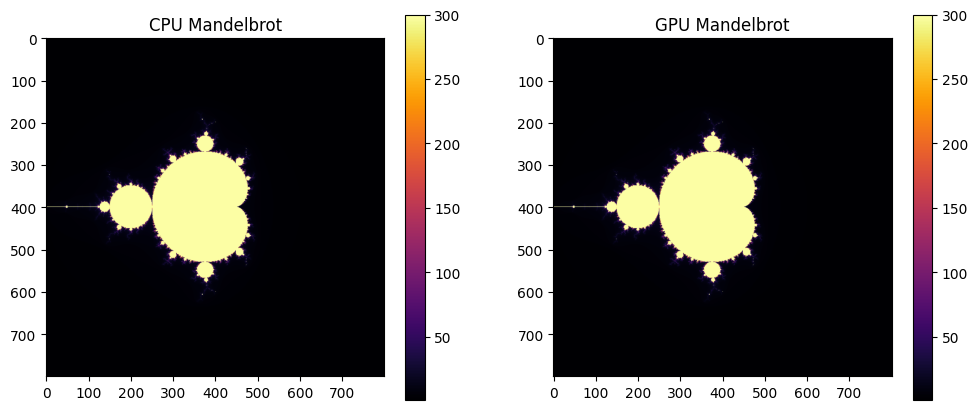

In [2]:
# ================= INSTALL =================
!pip install numba

# ================= IMPORTS =================
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import cuda, njit
import math

# ================= GPU KERNEL =================
@cuda.jit
def mandelbrot_gpu(image, max_iter):
    x, y = cuda.grid(2)

    height = image.shape[0]
    width = image.shape[1]

    if x < width and y < height:
        zx = 0.0
        zy = 0.0

        cx = (x - width/2.0) * 4.0 / width
        cy = (y - height/2.0) * 4.0 / height

        iter = 0
        while zx*zx + zy*zy < 4.0 and iter < max_iter:
            temp = zx*zx - zy*zy + cx
            zy = 2.0*zx*zy + cy
            zx = temp
            iter += 1

        image[y, x] = iter


# ================= CPU FUNCTION =================
@njit
def mandelbrot_cpu(width, height, max_iter):
    image = np.zeros((height, width))

    for x in range(width):
        for y in range(height):
            zx, zy = 0.0, 0.0

            cx = (x - width/2.0) * 4.0 / width
            cy = (y - height/2.0) * 4.0 / height

            iter = 0
            while zx*zx + zy*zy < 4 and iter < max_iter:
                temp = zx*zx - zy*zy + cx
                zy = 2*zx*zy + cy
                zx = temp
                iter += 1

            image[y, x] = iter

    return image


# ================= PARAMETERS =================
width, height = 800, 800
max_iter = 300

# ================= CHECK GPU =================
gpu_available = cuda.is_available()
print("CUDA Available:", gpu_available)


# ================= GPU EXECUTION =================
if gpu_available:
    print("\nRunning on GPU...\n")

    threads_per_block = (16, 16)

    gpu_img = np.zeros((height, width), dtype=np.float32)
    d_image = cuda.to_device(gpu_img)

    blocks_per_grid_x = math.ceil(width / 16)
    blocks_per_grid_y = math.ceil(height / 16)

    # Warm-up
    mandelbrot_gpu[(blocks_per_grid_x, blocks_per_grid_y), threads_per_block](d_image, max_iter)
    cuda.synchronize()

    # Timing
    start = time.time()
    mandelbrot_gpu[(blocks_per_grid_x, blocks_per_grid_y), threads_per_block](d_image, max_iter)
    cuda.synchronize()
    gpu_time = time.time() - start

    gpu_img = d_image.copy_to_host()

    print(f"GPU Time: {gpu_time:.4f} sec")


# ================= CPU EXECUTION =================
print("\nRunning on CPU...\n")

start = time.time()
cpu_img = mandelbrot_cpu(width, height, max_iter)
cpu_time = time.time() - start

print(f"CPU Time: {cpu_time:.4f} sec")


# ================= SPEEDUP =================
if gpu_available:
    speedup = cpu_time / gpu_time
    print(f"\nSpeedup = {speedup:.2f}x")


# ================= PLOTTING =================
plt.figure(figsize=(12,5))

# CPU Plot
plt.subplot(1,2,1)
plt.imshow(cpu_img, cmap='inferno')
plt.title("CPU Mandelbrot")
plt.colorbar()

# GPU Plot (only if available)
plt.subplot(1,2,2)
if gpu_available:
    plt.imshow(gpu_img, cmap='inferno')
    plt.title("GPU Mandelbrot")
else:
    plt.text(0.5, 0.5, "GPU Not Available", ha='center')
    plt.title("GPU Mandelbrot")

plt.colorbar()

plt.show()